<a href="https://colab.research.google.com/github/DCDPUAEM/DCDP_2022/blob/main/02-Machine-Learning/notebooks/11-Regresion-Logistica-SOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Logística

En esta notebook aprenderás a usar la **Regresión Logística** como modelo de clasificación en distintos escenarios.

##  Objetivos de aprendizaje

Al finalizar esta notebook deberías poder:

- reconocer cuándo usar Regresión Logística;
- entrenar un clasificador binario y multiclase con `scikit-learn`;
- interpretar probabilidades, frontera de decisión y métricas de desempeño;
- identificar señales de *overfitting*;
- comparar la Regresión Logística con otros clasificadores.


Aunque su nombre incluye la palabra *regresión*, este modelo se usa principalmente para **clasificación**.  
El modelo estima probabilidades y, a partir de ellas, asigna una clase.


## Ejemplo 1(a)

La función `make_blobs` de scikit-learn genera datos artificiales agrupados en **clusters**.

En este primer ejemplo usaremos un problema muy simple para observar:
- cómo se ven los datos de dos clases;
- cómo aprende el clasificador;
- y cómo interpreta una frontera de decisión lineal.

>> La idea es empezar con un caso fácil antes de pasar a conjuntos de datos más realistas.


### Paso 1: Generación y visualización de datos simples

Primero construiremos un conjunto de datos artificial para entender el comportamiento básico del clasificador antes de pasar a ejemplos más realistas.


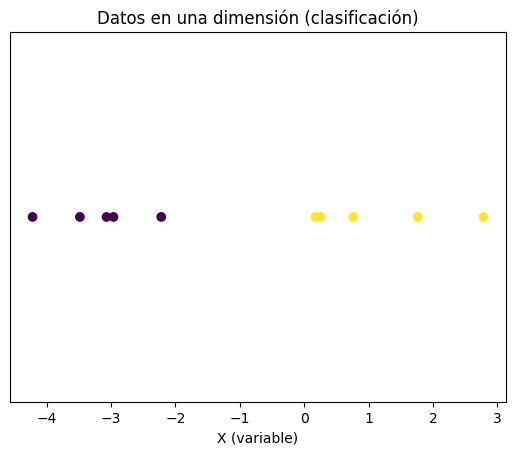

In [ ]:
# ============================================
# 1. Generar un dataset artificial sencillo
# ============================================

from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Creamos 10 datos con:
# - 1 sola variable (n_features=1)
# - 2 clases (centers=2)
# Esto simula un problema de clasificación binaria simple
X, y = make_blobs(
    n_samples=10,
    n_features=1,
    centers=2,
    random_state=17
)

# ============================================
# 2. Visualizar los datos
# ============================================

# Todos los puntos se colocan en y=0 para verlos en una línea (1D)
plt.figure()
plt.scatter(x=X, y=[0 for _ in X], c=y)

plt.title("Datos en una dimensión (clasificación)")
plt.xlabel("X (variable)")
plt.yticks([])  # quitamos eje Y porque no aporta información
plt.show()


In [ ]:
print(X,y)

[[ 1.76404536]
 [-2.22006102]
 [-2.96138866]
 [ 2.78299211]
 [-4.21839824]
 [-3.06950948]
 [ 0.17395196]
 [ 0.76041016]
 [ 0.24963377]
 [-3.48279883]] [1 0 0 1 0 0 1 1 1 0]


In [ ]:
# ============================================
# 3. Crear y entrenar el modelo
# ============================================

from sklearn.linear_model import LogisticRegression

# Creamos el modelo de regresión logística
lr = LogisticRegression()

# Entrenamos el modelo con los datos
# El modelo aprende una frontera de decisión (un umbral)
lr.fit(X, y)

# ============================================
# 4. Obtener probabilidades
# ============================================

# predict_proba devuelve:
# [probabilidad_clase_0, probabilidad_clase_1]
probs = lr.predict_proba(X)

print("Probabilidades [clase 0, clase 1]:")
print(probs)

# Nos quedamos solo con la probabilidad de clase 1
probs_clase_1 = probs[:, 1]

print("\nProbabilidad de pertenecer a la clase 1:")
print(probs_clase_1)
# ============================================
# 5. Interpretación
# ============================================

# Podemos ver cómo cambia la probabilidad según X
for i in range(len(X)):
    print(f"X = {X[i][0]:.2f} -> P(clase 1) = {probs_clase_1[i]:.2f}")

Probabilidades [clase 0, clase 1]:
[[0.02285015 0.97714985]
 [0.80783287 0.19216713]
 [0.91698049 0.08301951]
 [0.0061602  0.9938398 ]
 [0.98270709 0.01729291]
 [0.92709524 0.07290476]
 [0.15661428 0.84338572]
 [0.07959595 0.92040405]
 [0.14402441 0.85597559]
 [0.95612139 0.04387861]]

Probabilidad de pertenecer a la clase 1:
[0.97714985 0.19216713 0.08301951 0.9938398  0.01729291 0.07290476
 0.84338572 0.92040405 0.85597559 0.04387861]
X = 1.76 -> P(clase 1) = 0.98
X = -2.22 -> P(clase 1) = 0.19
X = -2.96 -> P(clase 1) = 0.08
X = 2.78 -> P(clase 1) = 0.99
X = -4.22 -> P(clase 1) = 0.02
X = -3.07 -> P(clase 1) = 0.07
X = 0.17 -> P(clase 1) = 0.84
X = 0.76 -> P(clase 1) = 0.92
X = 0.25 -> P(clase 1) = 0.86
X = -3.48 -> P(clase 1) = 0.04


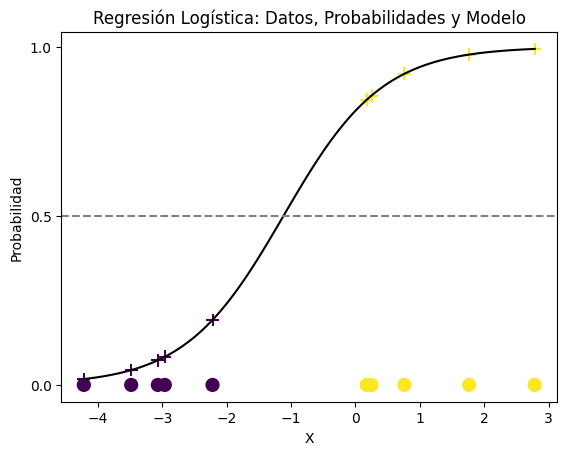

In [ ]:
# ============================================
# 6. Visualización de la función sigmoide
# ============================================

from math import e

# IMPORTANTE:
# lr.intercept_ y lr.coef_ son arrays → los convertimos a escalares
w0 = lr.intercept_[0]   # término independiente (bias)
w1 = lr.coef_[0][0]     # peso de la variable X

# Función lineal: z = w0 + w1*x
def f(x):
    return w0 + w1 * x

# Función sigmoide (logística)
# Convierte cualquier valor en una probabilidad entre 0 y 1
def plog(x):
    return 1 / (1 + e**(-f(x)))

# Rango de valores para graficar la curva
xmin, xmax = np.min(X), np.max(X)
xs = np.linspace(xmin, xmax, 100)

# ============================================
# Gráfica
# ============================================

plt.figure()

# 1. Datos originales (en línea horizontal)
plt.scatter(x=X, y=[0 for _ in X], c=y, s=85)
# → puntos reales del dataset

# 2. Curva sigmoide (modelo aprendido)
plt.plot(xs, [plog(x) for x in xs], color='black')
# → cómo el modelo transforma X en probabilidades

# 3. Probabilidades predichas por el modelo
plt.scatter(x=X, y=probs[:,1], c=y, marker='+', s=85)
# → probabilidad de clase 1 para cada punto

# 4. Umbral de decisión (0.5)
plt.axhline(y=0.5, color='gray', linestyle='--')
# → arriba: clase 1, abajo: clase 0

plt.yticks([0, 0.5, 1])
plt.title("Regresión Logística: Datos, Probabilidades y Modelo")
plt.xlabel("X")
plt.ylabel("Probabilidad")

plt.show()

## Ejemplo 1(b)

En este ejemplo clasificamos un pequeño conjunto de datos en 2 dimensiones.

Este tipo de ejemplo es útil porque podemos **visualizar los puntos y la frontera de decisión**.  
Cuando la clasificación se puede ver en el plano, es mucho más fácil entender qué está haciendo el modelo.


In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# 1. Generar un dataset artificial
# ============================================
# Creamos 10 muestras, con 2 variables de entrada
# y 2 clases diferentes
X, y = make_blobs(
    n_samples=10,
    n_features=2,
    centers=2,
    random_state=20
)

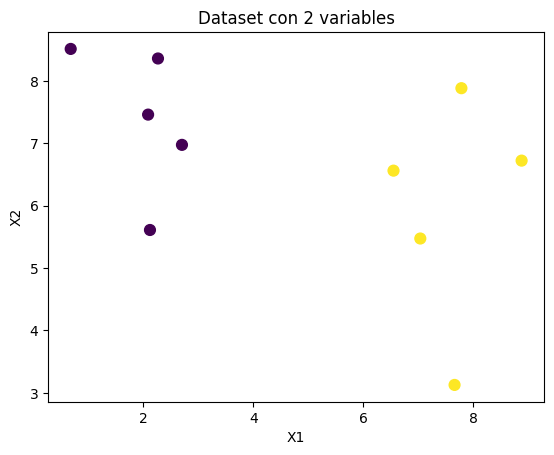

In [ ]:
# Visualización de los datos en 2D
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, s=60)
plt.title("Dataset con 2 variables")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [ ]:
# ============================================
# 2. Entrenar el modelo de regresión logística
# ============================================
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X, y)

# ============================================
# 3. Acceder al intercepto y coeficientes
# ============================================
# Modelo: z = w0 + w1*x1 + w2*x2
w0 = lr.intercept_[0]
w1 = lr.coef_[0, 0]
w2 = lr.coef_[0, 1]

print("Intercepto (w0):", w0)
print("Coeficiente para X1 (w1):", w1)
print("Coeficiente para X2 (w2):", w2)

# ============================================
# 4. Obtener probabilidades
# ============================================
# predict_proba devuelve:
# [P(clase 0), P(clase 1)]
probs = lr.predict_proba(X)

print("\nProbabilidades:")
print(probs)


Intercepto (w0): -4.129686005963528
Coeficiente para X1 (w1): 1.1273801628765636
Coeficiente para X2 (w2): -0.1825677622297573

Probabilidades:
[[0.95851277 0.04148723]
 [0.00941522 0.99058478]
 [0.99275335 0.00724665]
 [0.01912653 0.98087347]
 [0.94069125 0.05930875]
 [0.05699845 0.94300155]
 [0.11326529 0.88673471]
 [0.95696523 0.04303477]
 [0.03882339 0.96117661]
 [0.91348614 0.08651386]]


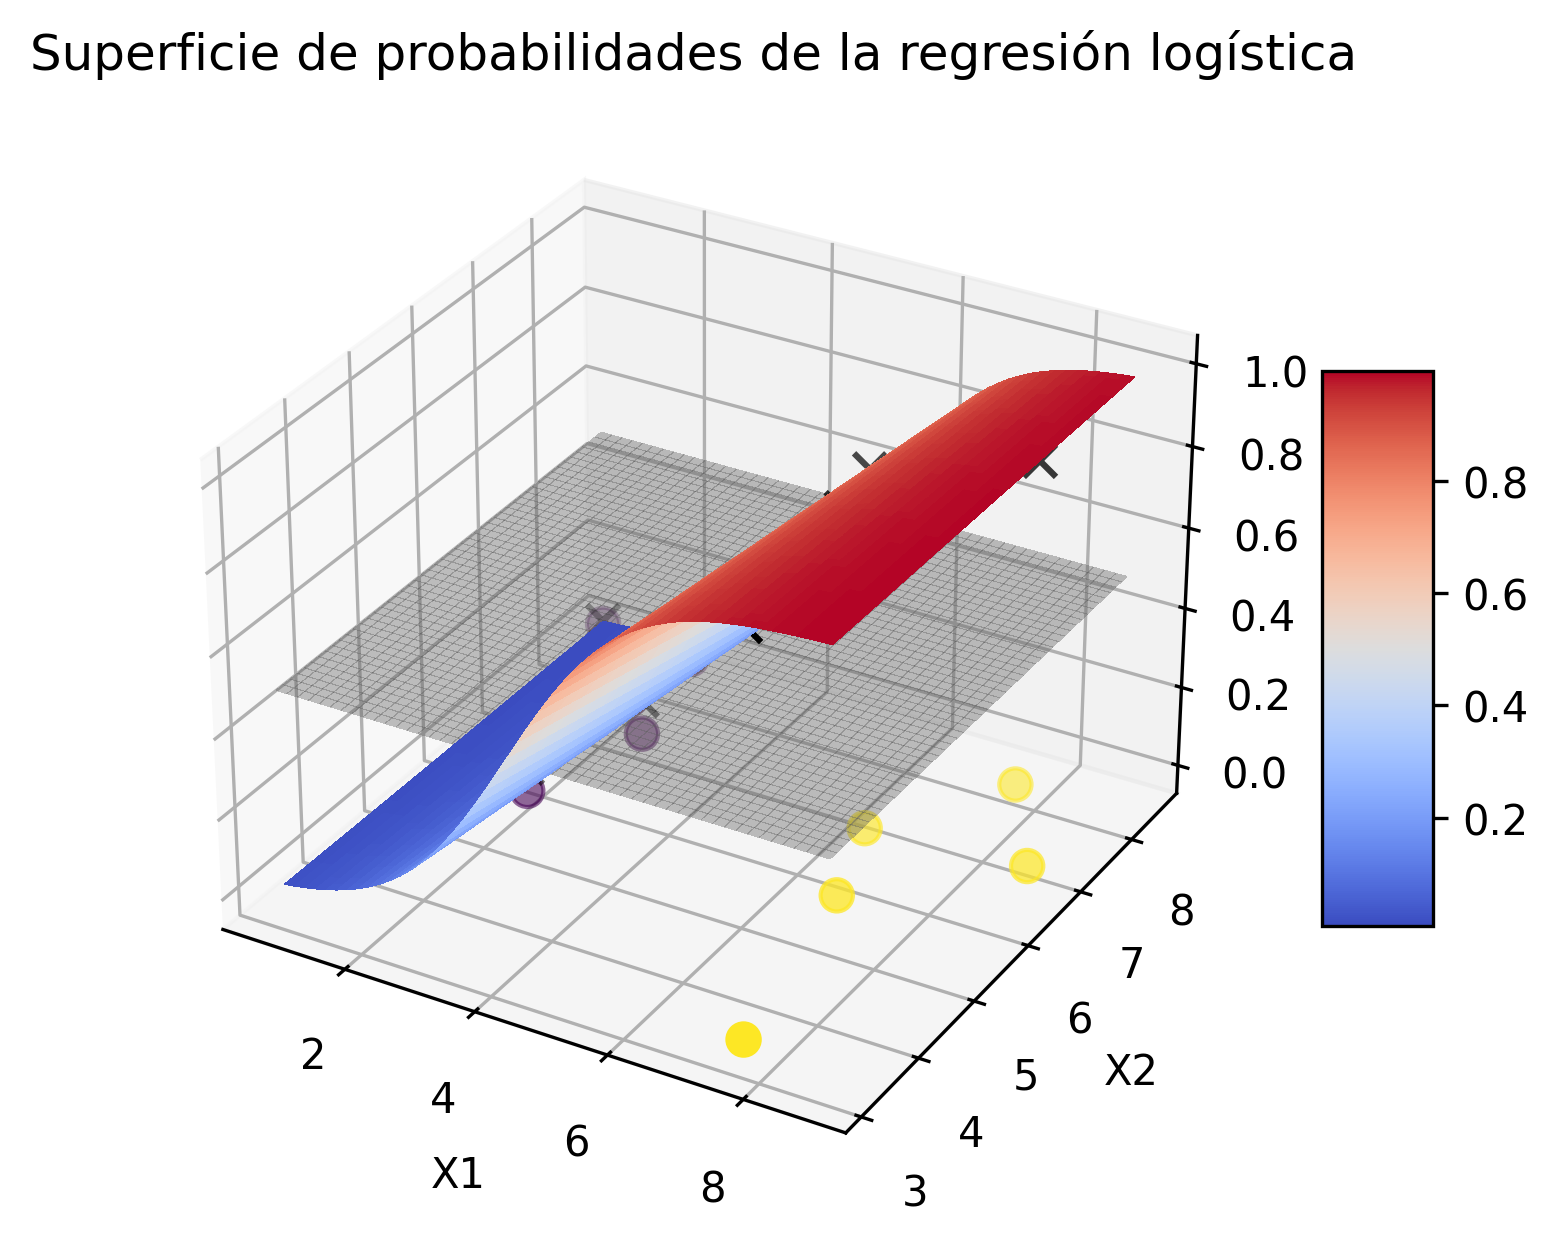

In [ ]:
# ============================================
# 5. Graficar la superficie de probabilidades
# ============================================
from math import e
from matplotlib import cm

# Función lineal
def f(x1, x2):
    return w0 + w1*x1 + w2*x2

# Función sigmoide
def plog(x1, x2):
    return 1 / (1 + np.exp(-f(x1, x2)))

# Creamos figura 3D
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, dpi=300)

# Rango de valores para construir la malla
xmin, xmax = np.min(X[:, 0]), np.max(X[:, 0])
ymin, ymax = np.min(X[:, 1]), np.max(X[:, 1])

xs = np.linspace(xmin, xmax, 50)
ys = np.linspace(ymin, ymax, 50)

# Malla 2D
Xs, Ys = np.meshgrid(xs, ys)

# Probabilidades en toda la malla
Z = plog(Xs, Ys)

# Superficie de probabilidades
surf = ax.plot_surface(
    Xs, Ys, Z,
    cmap=cm.coolwarm,
    linewidth=0,
    antialiased=False
)

fig.colorbar(surf, shrink=0.5, aspect=5)

# Plano horizontal en probabilidad 0.5
ax.plot_surface(
    Xs, Ys, 0.5 + np.zeros_like(Z),
    linewidth=0,
    antialiased=False,
    alpha=0.4,
    color='gray'
)

# Puntos originales en z=0
ax.scatter(X[:, 0], X[:, 1], [0 for _ in X], c=y, s=60)

# Probabilidad predicha para cada punto
ax.scatter(
    X[:, 0],
    X[:, 1],
    [plog(x[0], x[1]) for x in X],
    c='black',
    s=60,
    marker='x'
)

ax.set_title("Superficie de probabilidades de la regresión logística")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("P(clase 1)")

plt.show()

## Ejemplo 2(a)

En el siguiente ejemplo veremos cómo obtener **fronteras de decisión más complejas**.

La Regresión Logística básica produce fronteras lineales. Sin embargo, si transformamos las variables de entrada, por ejemplo con **características polinomiales**, el modelo puede separar datos con formas más complejas.

>> Observa cómo cambia la frontera cuando enriquecemos la representación de los datos.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import pandas as pd

url = '/content/sample_data/binary-classification-data.csv'
df = pd.read_csv(url,header=None)
df

,0,1,2
0,0.051267,0.699560,1
1,-0.092742,0.684940,1
2,-0.213710,0.692250,1
3,-0.375000,0.502190,1
4,-0.513250,0.465640,1
...,...,...,...
113,-0.720620,0.538740,0
114,-0.593890,0.494880,0
115,-0.484450,0.999270,0
116,-0.006336,0.999270,0


### Observemos los datos

Antes de entrenar un modelo, conviene mirar cómo se distribuyen las clases.

Preguntas guía:
- ¿las clases parecen separables con una línea recta?
- ¿hay regiones donde la separación se ve más difícil?
- ¿parece necesario usar características no lineales?


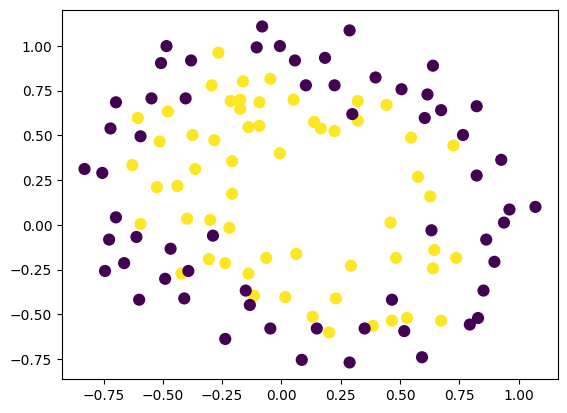

In [ ]:
import matplotlib.pyplot as plt

X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

plt.figure()
plt.scatter(X[:,0],X[:,1],c=y,s=60)
plt.show()

In [ ]:
#@title Funciones para graficas las fronteras de decisión
import numpy as np

def make_meshgrid(x, y, h=.02):
    '''
    función para hacer la malla de puntos para colorear las regiones de decisión,
    la malla de puntos abarca la región donde se encuentran los puntos (x,y)
    'h' es el tamaño de paso
    '''
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

Entrenamos una Regresión Logística con los parámetros por defecto y observamos su `accuracy` en el conjunto de entrenamiento.

⚠️ Recuerda: un buen resultado en entrenamiento **no garantiza** que el modelo generalice bien.  
Más adelante compararemos entrenamiento y prueba para detectar posibles problemas.


### Interpretación esperada

Después de entrenar, compara la frontera de decisión con la distribución original de los puntos.

Pregúntate:
- ¿el modelo separa correctamente ambas clases?
- ¿qué errores parecen inevitables?


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X,y)
lr.score(X,y)

0.5423728813559322

Ahora repetimos el entrenamiento, pero usando **características polinomiales**.

La idea es que el modelo siga siendo lineal en sus parámetros, pero ahora trabaje con una representación más rica de los datos, lo que puede producir fronteras de decisión no lineales.

---
```python
PolynomialFeatures(2, include_bias=False)
```
Genera nuevas variables como: $x_1^2$, $x_2^2$, $x_1 x_2$.

Permite que el modelo capture relaciones no lineales; "include_bias=False" evita agregar una columna de unos (la regresión logística ya maneja el intercepto).

---

```python
log_reg = LogisticRegression(penalty='l2', C=1, solver='newton-cholesky')
```
penalty='l2' → regularización Ridge (evita coeficientes grandes);

C=1 → controla la regularización:
* menor C → más regularización
* mayor C → menos regularización

solver='newton-cholesky' → método de optimización eficiente para datasets pequeños o medianos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

p_feats = PolynomialFeatures(2,include_bias=False)
log_reg = LogisticRegression(penalty='l2', C=1, solver='newton-cholesky')
#log_reg = LogisticRegression() #¿regularización? siii

pl = Pipeline([('pf',p_feats),
               ('clf',log_reg)])
pl.fit(X,y)
pl.score(X,y)

0.8135593220338984

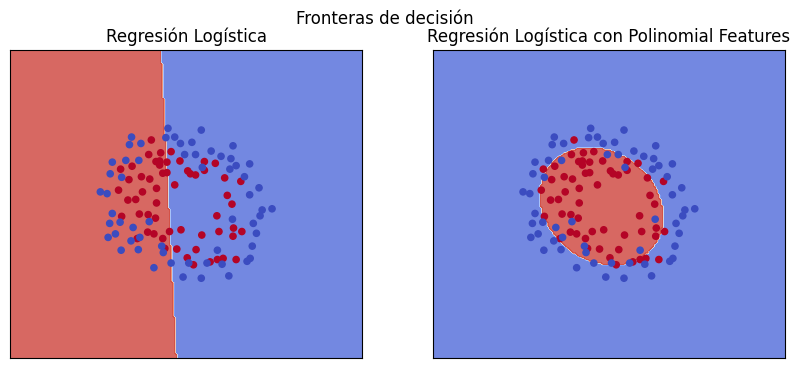

In [ ]:
xx, yy = make_meshgrid(X[:,0], X[:,1])

fig, (ax1, ax2) = plt.subplots(1,2,dpi=100,figsize=(10,4)) # El parámetro dpi especifíca los puntos por pulgada (DPI) de la imagen

fig.suptitle("Fronteras de decisión")

plot_contours(ax1, lr, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax1.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, s=20)
ax1.set_xticks(())
ax1.set_yticks(())
ax1.set_title('Regresión Logística')

plot_contours(ax2, pl, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax2.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, s=20)
ax2.set_xticks(())
ax2.set_yticks(())
ax2.set_title('Regresión Logística con Polinomial Features')

plt.show()

###Prueba con diferentes valores de regularización.

## Ejemplo 2(b)

En este ejemplo veremos el efecto de la **regularización** como herramienta para prevenir el *overfitting*.

Trabajaremos con un dataset que tiene muchas características, varias de ellas correlacionadas. En este contexto, la regularización ayuda a:
- controlar la complejidad del modelo;
- estabilizar los coeficientes;
- y mejorar la generalización.


### Dataset con muchas variables

Ahora trabajaremos con un problema más cercano a situaciones reales, donde hay varias variables y no todas aportan la misma información.


In [ ]:
from sklearn.datasets import make_classification
# ============================================
# 1. Generación del dataset
# ============================================
X, y = make_classification(n_samples=300,
                           n_features=60,
                           n_informative=20,
                           n_repeated=3,
                           n_redundant=20,
                           n_classes=2,
                           class_sep = 0.5,
                           random_state=57)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.75,random_state=1001)

Realizamos el entrenamiento y comparamos el desempeño en entrenamiento y prueba.

Si el rendimiento es muy bueno en entrenamiento pero claramente peor en prueba, eso es una señal de **overfitting**:  
el modelo aprendió demasiado bien los detalles del conjunto de entrenamiento, pero no generaliza igual de bien a datos nuevos.


In [ ]:
from sklearn.linear_model import LogisticRegression

# ============================================
# 2. Modelo sin regularización
# ============================================
lr = LogisticRegression(penalty=None)#especificar sin regularización
lr.fit(X_train,y_train)
print(f"Training score: {lr.score(X_train,y_train)}")
print(f"Test score: {lr.score(X_test,y_test)}")

Training score: 0.8266666666666667
Test score: 0.7066666666666667


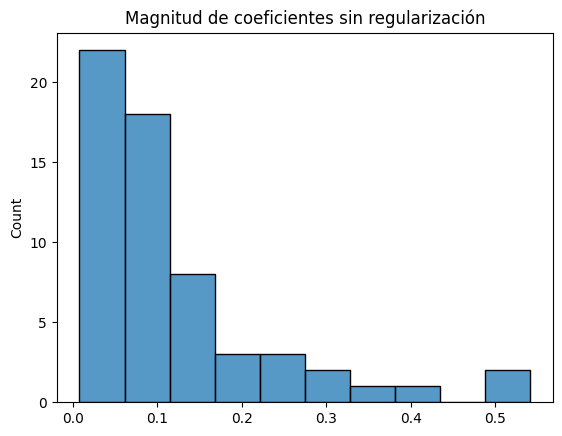

In [ ]:
# Magnitud de los coeficientes
import seaborn as sns
normas = np.abs(lr.coef_[0])

plt.figure()
sns.histplot(normas)
plt.title("Magnitud de coeficientes sin regularización")
plt.show()

Ahora usamos un clasificador con **regularización**.

La regularización penaliza coeficientes demasiado grandes.  
Esto suele hacer al modelo más estable y menos sensible al ruido o a la colinealidad entre variables.


In [ ]:
# ============================================
# 3. Modelo con regularización L1
#C controla la regularización:
#C pequeño → más regularización
#C grande → menos regularización
# ============================================
lr2 = LogisticRegression(C=0.1,penalty='l1',solver='liblinear')
lr2.fit(X_train,y_train)
print(f"Training score: {lr2.score(X_train,y_train)}")
print(f"Test score: {lr2.score(X_test,y_test)}")

Training score: 0.7955555555555556
Test score: 0.7466666666666667


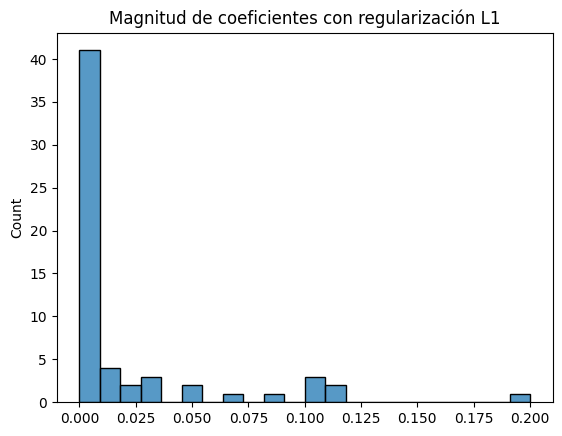

In [ ]:
import seaborn as sns

# Magnitud de los coeficientes
normas = np.abs(lr2.coef_[0])

plt.figure()
sns.histplot(normas)
plt.title("Magnitud de coeficientes con regularización L1")
plt.show()


Observa que varios coeficientes se vuelven exactamente cero.

Esto es consistente con el efecto de la regularización **L1**, que además de controlar la complejidad puede funcionar como un mecanismo de **selección de variables**.


In [ ]:
# ============================================
# 4. Número de coeficientes exactamente cero
# ============================================
coefs = lr2.coef_
num_zeros = coefs[coefs == 0].shape[0]
print(f"Número de coeficientes = 0: {num_zeros}")

Número de coeficientes = 0: 38


Veamos ahora el **ROC-AUC**.

Observa que en clasificación binaria usamos **solo la segunda columna** del arreglo de probabilidades: esa columna corresponde a la probabilidad estimada de pertenecer a la **clase positiva**.


ROC-AUC score: 0.8299856527977044


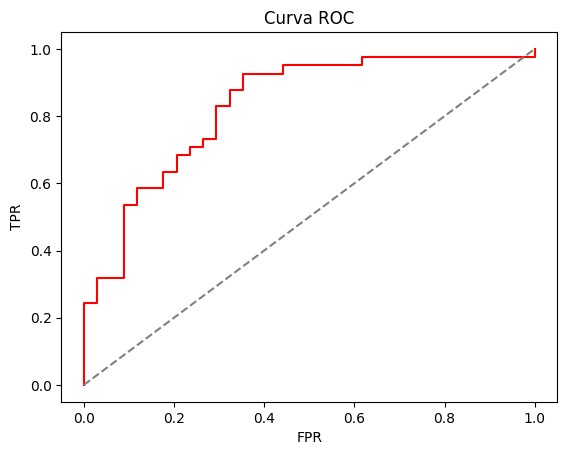

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# ============================================
# 5. ROC-AUC
# ============================================
# Solo usamos la segunda columna: probabilidad de la clase positiva
y_pred_probs = lr2.predict_proba(X_test)
score = roc_auc_score(y_test, y_pred_probs[:, 1])

print(f"ROC-AUC score: {score}")

# ============================================
# 6. Curva ROC
# ============================================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs[:, 1])

plt.figure()
plt.title("Curva ROC")
plt.plot(fpr, tpr, color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

### ROC-AUC

Imagina que el modelo le asigna a cada ejemplo una **probabilidad de ser positivo** (por ejemplo, ser admitido).

Luego tú decides un **umbral**, por ejemplo:
- si la probabilidad ≥ 0.5 → clase 1  
- si la probabilidad < 0.5 → clase 0  

Pero… ¿qué pasa si cambias ese umbral?  
>> El modelo se vuelve más o menos estricto.

---

### ¿Qué mide la curva ROC?

La curva ROC muestra qué pasa cuando cambias ese umbral:

- **TPR (sensibilidad)**: qué tantos positivos detectas bien  
- **FPR**: qué tantos negativos clasificas mal  

Cada punto en la curva es un umbral distinto.

---

### ¿Qué queremos?

👉 Detectar muchos positivos (TPR alto)  
👉 Equivocarnos poco con negativos (FPR bajo)

Por eso queremos la curva **arriba a la izquierda**.

---

### ¿Y el AUC?

El AUC es un número que resume todo:

- **AUC ≈ 1** → el modelo distingue muy bien  
- **AUC ≈ 0.5** → el modelo está adivinando  

---

### Resumen

>> ROC-AUC mide qué tan bien el modelo separa las clases  
sin depender de un solo umbral.

## Ejemplo 3

En este último ejemplo trabajaremos con un problema **multiclase**: reconocimiento de dígitos escritos a mano.

Aquí ya no se trata de decidir entre dos clases, sino entre **10 clases posibles** (los dígitos de 0 a 9).  
Esto nos permitirá ver cómo la Regresión Logística también puede extenderse a clasificación multiclase.


## Ejercicio: Clasificación de dígitos con Regresión Logística

En este ejercicio usaremos el conjunto de datos `load_digits` de scikit-learn, que contiene imágenes de dígitos escritos a mano.

Cada imagen tiene tamaño **8 × 8**, por lo que cada instancia se representa con **64 características** (pixeles aplanados).

El objetivo es entrenar un modelo de **Regresión Logística** para predecir qué dígito aparece en cada imagen.

In [ ]:
# Obtener el dataset
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()
X = digits.data
y = digits.target

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (1797, 64)
Forma de y: (1797,)


### Exploración del conjunto de datos

Antes de entrenar el modelo, veamos cómo se representa una instancia del conjunto de datos.

Cada ejemplo corresponde a una imagen de tamaño **8 × 8**, aplanada en un vector de **64 características**.  
En otras palabras, cada característica representa la intensidad de un píxel.


In [ ]:
X[28].reshape(8, 8)

array([[ 0.,  0., 10., 11.,  4.,  0.,  0.,  0.],
       [ 0.,  0., 10., 15., 13., 13.,  1.,  0.],
       [ 0.,  0.,  8., 11.,  0., 14.,  4.,  0.],
       [ 0.,  0.,  0., 13., 15., 13.,  0.,  0.],
       [ 0.,  1., 11., 16., 16.,  0.,  0.,  0.],
       [ 0.,  1., 15.,  3.,  9., 10.,  0.,  0.],
       [ 0.,  0., 14.,  6., 15., 10.,  0.,  0.],
       [ 0.,  0.,  8., 14.,  7.,  1.,  0.,  0.]])

Mostremos también la imagen correspondiente.

Esto es importante porque conecta la representación numérica con el objeto real que queremos clasificar.


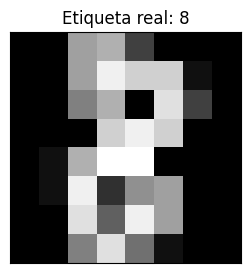

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.imshow(X[28].reshape(8,8), cmap=plt.cm.gray)
plt.title(f"Etiqueta real: {y[28]}")
plt.xticks([])
plt.yticks([])
plt.show()

### División en entrenamiento y prueba

Dividimos los datos en un conjunto de entrenamiento y otro de prueba.

- **Entrenamiento**: se usa para ajustar el modelo  
- **Prueba**: se usa para evaluar qué tan bien generaliza el modelo

⚠️ Esta separación es fundamental para evaluar el modelo con datos nunca antes vistos.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=128,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1437, 64)
X_test: (360, 64)


### Visualización de algunas imágenes de entrenamiento

Antes de entrenar, veamos algunos ejemplos del conjunto de entrenamiento junto con su etiqueta real.

Esto ayuda a familiarizarse con la tarea y a recordar que el modelo está aprendiendo a reconocer patrones visuales.


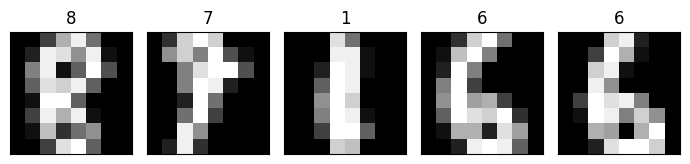

In [ ]:
plt.figure(figsize=(7,2))
for idx, (image, label) in enumerate(zip(X_train[:5], y_train[:5])):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(image.reshape(8,8), cmap=plt.cm.gray)
    plt.xticks([])
    plt.yticks([])
    plt.title(label)
plt.tight_layout()
plt.show()

### Entrenamiento del modelo

Usaremos la implementación de scikit-learn.

Como la Regresión Logística se entrena mediante optimización, suele ser conveniente **escalar los datos** antes del entrenamiento.  
Por eso usamos un **pipeline** que primero estandariza y luego ajusta el clasificador.

👉 Ventaja del pipeline: evita errores y ayuda a prevenir *data leakage*.


### ⚠️ ¿Qué es *data leakage*?

El *data leakage* (fuga de información) ocurre cuando el modelo utiliza información que **no debería conocer durante el entrenamiento**, especialmente información del conjunto de prueba.

---

### ¿Por qué es un problema?

Porque el modelo parece tener un desempeño muy alto, pero en realidad:

👉 está "haciendo trampa"  
👉 no generaliza bien a datos nuevos  

---

### 🔍 Ejemplo típico

Supongamos que normalizamos los datos usando **todo el dataset** antes de dividir en entrenamiento y prueba:

```python
scaler.fit(X_all)  # ❌ usa información de train y test

### ¿Por qué usar un pipeline?

Porque así garantizamos que el mismo preprocesamiento se aplique de forma consistente en entrenamiento, validación y prueba.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline: escalado + modelo
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        C=0.1,
        max_iter=2000
    ))
])

lr.fit(X_train, y_train)

print(f"Training accuracy: {lr.score(X_train, y_train):.4f}")
print(f"Test accuracy: {lr.score(X_test, y_test):.4f}")

Training accuracy: 0.9875
Test accuracy: 0.9667


## Predicciones

Una vez entrenado el modelo, podemos usarlo para predecir:
- la **clase** de cada ejemplo;
- y las **probabilidades** asociadas a cada clase.


In [ ]:
y_pred = lr.predict(X_test)
print("Forma de y_pred:", y_pred.shape)

Forma de y_pred: (360,)


In [ ]:
y_pred_probs = lr.predict_proba(X_test)
print("Forma de y_pred_probs:", y_pred_probs.shape)

Forma de y_pred_probs: (360, 10)


Veamos las probabilidades predichas para una instancia junto con la etiqueta estimada.

Esto ayuda a entender que el modelo no solo “elige una clase”, sino que también expresa su nivel de confianza en cada posible clase.


In [ ]:
print("Probabilidades predichas:")
print(y_pred_probs[0])

print("\nEtiqueta predicha:")
print(y_pred[0])

print("\nSuma de probabilidades:")
print(np.sum(y_pred_probs[0]))

Probabilidades predichas:
[7.67476312e-05 2.06413360e-03 9.89552902e-01 2.11693802e-03
 3.03720019e-05 2.51092613e-03 1.16746706e-03 1.10298288e-05
 2.37398692e-03 9.54970557e-05]

Etiqueta predicha:
2

Suma de probabilidades:
1.0000000000000002


Como se trata de un problema con 10 clases, el modelo devuelve 10 probabilidades por instancia.

La suma de todas esas probabilidades es 1, porque representan cómo reparte el modelo su confianza entre todas las clases posibles.


### Métricas de rendimiento y matriz de confusión

No basta con medir solo la exactitud global.

También conviene observar:
- el reporte de clasificación;
- la matriz de confusión;
- y qué clases se confunden con mayor frecuencia.

👉 La matriz de confusión permite ver **dónde** se equivoca el modelo, no solo cuánto acierta.


### ¿Cómo leer la matriz de confusión?

- La diagonal principal muestra los aciertos
- Los valores fuera de la diagonal muestran confusiones entre clases

Si una clase se confunde mucho con otra, suele indicar que sus patrones son parecidos para el modelo.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.94      0.94      0.94        36
           2       1.00      0.97      0.99        35
           3       0.97      0.89      0.93        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.83      0.97      0.89        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



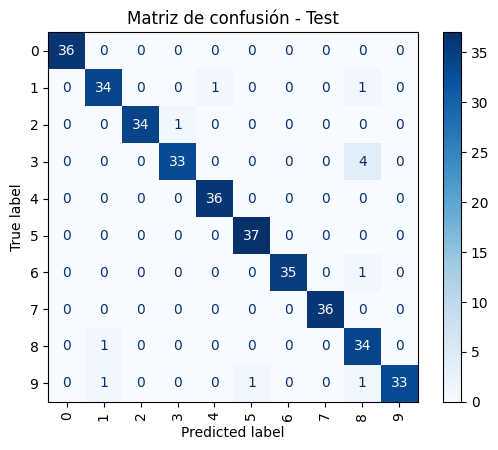

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de confusión - Test")
plt.show()

### Validación cruzada

Usaremos validación cruzada para obtener una evaluación más robusta del modelo.

Observa que aplicamos `cross_val_score` sobre el **pipeline completo**, para que el escalado se ajuste correctamente dentro de cada partición y evitar *data leakage*.


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr, X_train, y_train, cv=5)

print("Scores de validación cruzada:")
print(scores)

print(f"Promedio: {np.mean(scores):.4f}")

Scores de validación cruzada:
[0.95833333 0.94444444 0.9825784  0.96167247 0.96167247]
Promedio: 0.9617


### ROC-AUC Score

Usaremos el área bajo la curva ROC como métrica adicional.

En problemas multiclase, `predict_proba` devuelve una probabilidad por cada clase. Para calcular ROC-AUC debemos indicar una estrategia multiclase, por ejemplo:

- `ovr` (*one-vs-rest*)
- `ovo` (*one-vs-one*)

En este caso usaremos `ovr`.


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred_probs = lr.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_pred_probs,
    multi_class='ovr'
)

print(f"ROC-AUC (OvR): {roc_auc:.4f}")

ROC-AUC (OvR): 0.9990


### Comentario final

En problemas multiclase no existe una única curva ROC como en clasificación binaria.  
Sin embargo, sí podemos calcular un valor global de ROC-AUC usando estrategias como `ovr` o `ovo`.

👉 Lo importante es recordar que esta métrica resume qué tan bien separa el modelo las clases en términos probabilísticos.


## ⭕ Tarea

Realiza el entrenamiento de un modelo de **Regresión Logística** y genera predicciones sobre un nuevo conjunto de datos de clasificación.

Tu reporte debe incluir:

1. descripción breve del dataset;
2. partición en entrenamiento y prueba;
3. entrenamiento del modelo;
4. predicciones;
5. métricas de rendimiento;
6. matriz de confusión;
7. una breve interpretación de resultados.

👉 No solo ejecutes el código: explica qué significan tus resultados.


### Guía sugerida para resolver la práctica

1. Explora el dataset  
2. Atiende los valores faltantes  
3. Define un pipeline  
4. Ajusta y evalúa varios clasificadores  
5. Compara resultados y redacta una conclusión


## ⭕ Práctica integral de clasificación

En esta práctica trabajarás con el dataset **diabetes**.

Recuerda que este conjunto de datos contiene **valores faltantes**, así que el preprocesamiento será parte importante del ejercicio.

### Objetivo

Calcular al menos las métricas:
- **accuracy**
- **F1-score**

Además, reflexiona sobre:
- qué pipeline funciona mejor;
- si el escalado ayuda;
- y si la selección de variables mejora el resultado.


In [ ]:
import pandas as pd
import numpy as np

url = '/content/sample_data/diabetes.csv'
df = pd.read_csv(url,index_col=0)
df

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
from sklearn.impute import SimpleImputer

features_with_missing_values = ['glucose','skin','bmi']
missing_values_columns = df.loc[:,features_with_missing_values].values

imputador = SimpleImputer(missing_values=0,strategy='mean')
imputed_values_columns = imputador.fit_transform(missing_values_columns)

df[features_with_missing_values] = imputed_values_columns
df

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148.0,72,35.00000,0,33.6,0.627,50,1
1,1,85.0,66,29.00000,0,26.6,0.351,31,0
2,8,183.0,64,29.15342,0,23.3,0.672,32,1
3,1,89.0,66,23.00000,94,28.1,0.167,21,0
4,0,137.0,40,35.00000,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76,48.00000,180,32.9,0.171,63,0
764,2,122.0,70,27.00000,0,36.8,0.340,27,0
765,5,121.0,72,23.00000,112,26.2,0.245,30,0
766,1,126.0,60,29.15342,0,30.1,0.349,47,1


In [ ]:
feature_names = df.columns.to_list()[:-1]

print(f"Nombres de las features: {feature_names}")

Nombres de las features: ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age']


### División en entrenamiento y prueba

Primero separamos los datos para entrenar y evaluar los modelos correctamente.


In [ ]:
from sklearn.model_selection import train_test_split

X = df.loc[:,feature_names].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

### Pipeline base

Definimos un pipeline con:
1. selector de variables,
2. escalador,
3. y Regresión Logística.

Esto permite encapsular todo el flujo de trabajo en un solo objeto y facilita la validación cruzada y la búsqueda de hiperparámetros.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, VarianceThreshold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

# selector = SelectKBest(k=5)
selector = VarianceThreshold(0.25)
scaler = MinMaxScaler()
clf = LogisticRegression()

pl = Pipeline([('selector',selector),
               ('escalador',scaler),
               ('clasificador',clf)])

pl.fit(X_train,y_train)

Pipeline(steps=[('selector', VarianceThreshold(threshold=0.25)),
                ('escalador', MinMaxScaler()),
                ('clasificador', LogisticRegression())])

In [ ]:
from sklearn.model_selection import cross_val_score

cvs = cross_val_score(pl,X_train,y_train)

print(f"Accuracy en el conjunto de entrenamiento: {pl.score(X_train,y_train)}")
print(f"CV Accuracy en el conjunto de entrenamiento: {np.mean(cvs)}")
print(f"Accuracy en el conjunto de prueba: {pl.score(X_test,y_test)}")

Accuracy en el conjunto de entrenamiento: 0.7579143389199255
CV Accuracy en el conjunto de entrenamiento: 0.7616649359640014
Accuracy en el conjunto de prueba: 0.7748917748917749


### Búsqueda de hiperparámetros

Ahora realizamos un `GridSearchCV` para explorar distintas combinaciones de parámetros y encontrar la configuración con mejor desempeño.


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "selector__threshold": [0,0.1,0.2,0.5],
    "clasificador__C": [0.1,0.5,1,2],
    "clasificador__solver": ['lbfgs','newton-cg','sag'],
    "clasificador__penalty": [None,'l2']
}

search = GridSearchCV(pl, param_grid, n_jobs=-1)
search.fit(X_train, y_train)
print("Best parameter (CV score=%0.3f):" % search.best_score_)
print(search.best_params_)

Best parameter (CV score=0.769):
{'clasificador__C': 1, 'clasificador__penalty': 'l2', 'clasificador__solver': 'newton-cg', 'selector__threshold': 0}


In [ ]:
selector = VarianceThreshold(0)
scaler = MinMaxScaler()
clf = LogisticRegression(C=1,penalty='l2',solver='lbfgs')#mejor modelo

best_pl = Pipeline([('selector',selector),
               ('escalador',scaler),
               ('clasificador',clf)])

best_pl.fit(X_train,y_train)

Pipeline(steps=[('selector', VarianceThreshold(threshold=0)),
                ('escalador', MinMaxScaler()),
                ('clasificador', LogisticRegression(C=1))])

In [ ]:
from sklearn.model_selection import cross_val_score

cvs = cross_val_score(best_pl,X_train,y_train)

print(f"Accuracy en el conjunto de entrenamiento: {best_pl.score(X_train,y_train)}")
print(f"CV Accuracy en el conjunto de entrenamiento: {np.mean(cvs)}")
print(f"Accuracy en el conjunto de prueba: {best_pl.score(X_test,y_test)}")

Accuracy en el conjunto de entrenamiento: 0.776536312849162
CV Accuracy en el conjunto de entrenamiento: 0.7672897196261682
Accuracy en el conjunto de prueba: 0.7792207792207793


### Comparación de varios clasificadores

Ahora repetimos la lógica para varios modelos.

En cada caso realizamos una búsqueda de hiperparámetros y registramos:
- el mejor `accuracy` en validación cruzada;
- y el `accuracy` final sobre el conjunto de prueba.

👉 Así comparamos modelos de forma más justa.


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score

selector = SelectKBest()
scaler = MinMaxScaler()


lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
svm = SVC()
nb = GaussianNB()

params_lr = {
            "selector__k": [2,3,4,5,6],
            "clasificador__C": [0.1,0.5,1,2],
            "clasificador__solver": ['lbfgs','newton-cg','sag'],
            "clasificador__penalty": [None,'l2']}
params_dt = {
            "selector__k": [2,3,4,5,6],
            "clasificador__criterion": ['gini','entropy','log_loss'],
            "clasificador__max_depth": [None,10,20],
            "clasificador__min_samples_split": [2,3,4]}
params_rf = {
            "selector__k": [2,3,4,5,6],
            "clasificador__n_estimators": [25,50,75,100],
            "clasificador__max_depth": [None,5,10]
            }
params_svm = {
            "selector__k": [2,3,4,5,6],
            "clasificador__C": [0.5,1,2],
            "clasificador__kernel": ['linear', 'poly', 'rbf']
            }
params_nb = {
            "selector__k": [2,3,4,5,6]
            }

clasificadores = [lr,dt,rf,svm,nb]
params_grids = [params_lr,params_dt,params_rf,params_svm,params_nb]

training_cv_accs = []
testing_accs = []

for j,(clf,param_grid) in enumerate(zip(clasificadores,params_grids)):
    pl = Pipeline([('selector',selector),
                ('escalador',scaler),
                ('clasificador',clf)])
    search = GridSearchCV(pl, param_grid, n_jobs=-1)
    search.fit(X_train, y_train)
    best_option = search.best_estimator_
    cvs = cross_val_score(best_option,X_train,y_train)
    training_cv_accs.append(np.mean(cvs))
    y_pred = best_option.predict(X_test)
    testing_accs.append(accuracy_score(y_test,y_pred))
    print(f"Clasificador {j+1} explorado")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and

Clasificador 1 explorado
Clasificador 2 explorado
Clasificador 3 explorado
Clasificador 4 explorado
Clasificador 5 explorado


### Resultados ordenados

Veamos los resultados ordenados por el `accuracy` obtenido en el conjunto de prueba.

Además de identificar el mejor modelo, observa si existe diferencia importante entre entrenamiento, validación y prueba.


In [ ]:
results_df = pd.DataFrame(data={
                        'clasificador':['LogReg','DT','RF','SVM','G Naive Bayes'],
                        'Training CV accuracy': training_cv_accs,
                        'Test Accuracy':testing_accs
                        })
results_df.sort_values(by='Test Accuracy',ascending=False)

,clasificador,Training CV accuracy,Test Accuracy
2,RF,0.733818,0.792208
3,SVM,0.765386,0.792208
0,LogReg,0.767255,0.779221
4,G Naive Bayes,0.752354,0.779221
1,DT,0.730062,0.748918


### Resultados ordenados

Revisa la tabla final con atención y responde:

- ¿qué modelo obtuvo mejor desempeño?
- ¿ese mismo modelo también fue estable?
- ¿algún modelo parece sobreajustado?


# ⭕ TAREA 2: Práctica integral de clasificación

Aplica este pipeline a diferentes datasets de **clasificación binaria y multiclase**.

### Sugerencias de datasets en `sklearn`

- `breast_cancer`
- `wine`
- `digits`
- `iris`

### Tu notebook debe incluir

1. descripción del dataset;
2. preprocesamiento aplicado;
3. modelo o modelos probados;
4. métricas de rendimiento;
5. matriz de confusión;
6. conclusiones.

👉 El objetivo es que puedas reproducir el flujo completo de clasificación en un problema nuevo.
